# Volatility and Corrleation of Par Yields



## Comparing the volatility and correlation of changes in par yields

Our empirical analysis examines the volatility and correlation of par yield changes from October 1993 to December 2025, offering a practical view on the application of duration and convexity. The subsequent notebook, titled *Changing Slope and Shape of Term Structure*, demonstrates how duration and convexity can be employed to construct a trade. This trade is designed to be perfectly hedged against parallel shifts in interest rates, though only partially immunized from non-parallel changes, with its performance dependent on volatility.


### Importing Libraries, Modules, and Functions
As in earlier chapters of the volume, modules that are included in the standard Python library are imported. When necessary, other modules or libraries are installed before they are imported.$^{2}$  As in Chapter Seven, FRED is used as the source for par yield data and this data is accessed utilizing pandas reader. Because <font color='green'>pandas_data_reader</font> is not part of the Pandas library, it is imported and when necessary installed.

```
import sys
import requests
from types import ModuleType
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd
try:
    import pandas_datareader as pdr
except:
    !pip install pandas-datareader
    import pandas_datareader as pdr
```
---


$^{2}$For more information on <font color='green'>try</font> and <font color='green'>except</font> statements, see “<a href='https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/Control_Statements.html#the-try-and-except'>Control Statements</a>.”

In [1]:
import sys
import requests
from types import ModuleType
from datetime import datetime,date
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd
try:
    import pandas_datareader as pdr
except:
    !pip install pandas-datareader
    import pandas_datareader as pdr

### Adding a custom module and importing functions


The <font color='green'>module_basic_concepts_fixed_income</font> custom module contains functions utilized in the notebooks within the "Basic Concepts of Fixed Income" volume. This module is accessed from Dropbox using <font color='green'>requests</font>.

You have the flexibility to choose the module name; in this instance,  <font color='green'>basic_concepts_fixed_income</font> is assigned to  <font color='green'>module_name</font>. The URL for access is provided by Dropbox. The module is instantiated with <font color='green'>ModuleType</font> using the chosen <font color='green'>module_name</font>. Once created, the module becomes accessible in the notebook's memory, though it is not added to a drive.
```
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=stuou11h&dl=1'
module_name='module_basic_concepts_fixed_income'
try:
  response=requests.get(url)
  module=ModuleType(module_name)

```
The <font color='green'>exec</font> function executes the Python code returned by <font color='green'>request.get</font>. It assigns functions and variables to <font color='green'>sys.module[module_name]</font>, making the module available to the notebook.
```
exec(response.text,module.__dict__)
sys.module[module_name]=module
```
The single function one_y_axis is imported:


```
from basic_concepts_fixed_income import(one_y_axis)
```

* **one_y_axis** ([Chapter One](https://patrickjhess.github.io/Vol-3-Chap-1/Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.html#graphing-the-spot-and-forward-rates-for-september-30-2025)): Plots multiple series against a single x axis.
  * [View Details](https://patrickjhess.github.io/Imported-Functions/one_y_axis.html#one-y-axis-is-a-helper-function-for-plotting-graphs-created-by-financial-python)  






In [2]:
# Define the URL of the Python module to be downloaded from Dropbox.
# The 'dl=1' parameter in the URL forces a direct download of the file content.
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=stuou11h&dl=1'
module_name='basic_concepts_fixed_income'
# Send an HTTP GET request to the URL and store the server's response.
try:
  response=requests.get(url)
  # Raise an exception for bad status codes (like 404 Not Found)
  response.raise_for_status()
  module= ModuleType(module_name)
  #Code contained in response.text executed
  exec(response.text, module.__dict__)
  # Module added to sys
  sys.modules[module_name]=module
except requests.exceptions.RequestException as e:
    print(f"❌ Error: Could not fetch module from URL. {e}")
except Exception as e:
    print(f"❌ Error: Failed to execute or import the module. {e}")
# Open the local file in "write binary" ('wb') mode and save the downloaded content.
# Using a 'with' statement ensures the file is properly closed after writing.

# Now that 'basic_concepts_fixed_income' exists in the notebook, import the specific functions
from basic_concepts_fixed_income import(one_y_axis)

## Use Pandas Reader to Access Par Yield Data from FRED between January 1$^{st}$ 1990 and December 31$^{st}$ 2025

Par yield data for five distinct maturities are sourced from the FRED database using the following series IDs:

* **Six months:** <font color='green'>dgs6mo</font>  
* **Five years:** <font color='green'>dgs5</font>  
* **Ten years:** <font color='green'>dgs10</font>  
* **Twenty years:** <font color='green'>dgs20</font>  
* **Thirty years:** <font color='green'>dgs30</font>

The <font color='green'>dropna</font> method is used with the <font color='how'>dropna</font> assigned *any*. This coding drops any row with missing data for any of the par yields. The first clean date is October 1${st}$ 1993.


In [3]:
# set the start and end dates
start_date = date(1990, 1, 1)
end_date = date(2025,12,31)

# series ids
series_ids = ['dgs6mo','dgs5','dgs10','dgs20','dgs30']
# use pandas reader to get data from fred
par_yields_daily = pdr.get_data_fred(series_ids, start_date, end_date)

# if any values are missing drop the row
par_yields_daily.dropna(how='any',inplace=True)
display(par_yields_daily )

,dgs6mo,dgs5,dgs10,dgs20,dgs30
DATE,,,,,
1993-10-01,3.11,4.72,5.34,6.12,5.98
1993-10-04,3.17,4.71,5.34,6.10,5.99
1993-10-05,3.20,4.72,5.35,6.12,6.01
1993-10-06,3.19,4.70,5.35,6.12,6.01
1993-10-07,3.17,4.69,5.33,6.11,6.01
...,...,...,...,...,...
2025-12-24,3.59,3.70,4.15,4.75,4.79
2025-12-26,3.58,3.68,4.14,4.76,4.81
2025-12-29,3.59,3.67,4.12,4.75,4.80


## Grouping the par yields by quarter

To empirically demonstrate the relationship between changes in par yield standard deviations and their correlations, calculations are performed for each calendar quarter. The Pandas <font color='green'>groupby</font> method is used to create specific data groupings. Changes in par yields are categorized into quarterly groups using <font color='green'>Grouper</font> with the frequency set to 'QS' for the start of the quarter.

The data grouping method is illustrated using data from the first quarter of 2025. After creating the <font color='green'>q1_group</font>, the <font color='green'>sum</font> method is applied to <font color='green'>q1_group</font>, and the DataFrame <font color='green'>par_yield_q1_2025</font> with identical results.


In [4]:
# create the DataFrame for q1 2025
par_yield_q1_2025=par_yields_daily.loc['2025-01-01':'2025-03-31']

# group the data by quarter
q1_group = par_yield_q1_2025.groupby(pd.Grouper(freq='QS'))

# display the results of applying sum method to the q1_group
display('Grouped Data',q1_group[['dgs6mo','dgs5','dgs10','dgs20','dgs30']].sum())

# display the results of applying sum method to the DataFrame for q1 2025
display('Raw Data',par_yield_q1_2025.sum())

'Grouped Data'

,dgs6mo,dgs5,dgs10,dgs20,dgs30
DATE,,,,,
2025-01-01,260.98,259.25,271.67,290.29,287.42


'Raw Data'

dgs6mo    260.98
dgs5      259.25
dgs10     271.67
dgs20     290.29
dgs30     287.42
dtype: float64

## Creating quarterly groups and calculating standard deviations
The <font color='green'>quarterly_groups</font> object is created after calculating the changes in par yields using the difference (<font color='green'>diff</font>) method. The standard deviation (<font color='green'>std</font>) method is then applied to these par yield changes, and the results are assigned to <font color='green'>quarterly_sigma_df</font>. The results for 129 quarters are displayed.



In [5]:
# calculate daily differences for all par yields
par_yield_changes = par_yields_daily.diff()

# want daily difference grouped by quarter with start of the quarter (QS)
quarterly_groups = par_yield_changes.groupby(pd.Grouper(freq='QS'))

# apply std method to calculate standard deviation of each quarter
quarterly_sigma_df = quarterly_groups[['dgs6mo','dgs5','dgs10','dgs20','dgs30']].std().round(4)

display(quarterly_sigma_df)

,dgs6mo,dgs5,dgs10,dgs20,dgs30
DATE,,,,,
1993-10-01,0.0232,0.0461,0.0499,0.0472,0.0448
1994-01-01,0.0374,0.0602,0.0616,0.0551,0.0529
1994-04-01,0.0694,0.1012,0.0987,0.0882,0.0846
1994-07-01,0.0594,0.0692,0.0637,0.0614,0.0571
1994-10-01,0.0683,0.0592,0.0544,0.0548,0.0497
...,...,...,...,...,...
2024-10-01,0.0210,0.0559,0.0566,0.0545,0.0560
2025-01-01,0.0176,0.0571,0.0536,0.0522,0.0509
2025-04-01,0.0230,0.0687,0.0615,0.0602,0.0603


## <font color='green'>Application: Calculate the standard deviations for 2025</font>
<div style="
    border-left: 12px solid green;
    line-height: 1.5;
    padding: 15px">

 see [Chapter Eight Hints: Calculate the standard deviations for 2025](https://colab.research.google.com/drive/1WL30MXvTfn3tTNQaaas2bmHn3G5E3lK4#scrollTo=m-SmcqAcL1FZ), and check the [expected results here](https://colab.research.google.com/drive/1jULdrPyul6Xs5Zrm4ysXezNNuJG7K6l6#scrollTo=m-SmcqAcL1FZ).

</div>    

## Calculate quarterly correlations of changes in par yields

There are ten unique correlations between par yields for five maturity dates.  The <font color='green'>calc_correl_par_yields</font> uses the <font color='green'>corr</font> Pandas method to calculate the correlation of the series for each quarter. The correlation results are a dictionary within a Pandas series that then forms the columns of a Dataframe.

In [6]:
def calc_correl_par_yields(data):
  # use the corr method to calculate correlations
  # each element of a pandas series column of correlations
  return pd.Series({
  '_6_mo_5_y':data['dgs6mo'].corr(data['dgs5']),
  '_6_mo_10_y':data['dgs6mo'].corr(data['dgs10']),
  '_6_mo_20_y':data['dgs6mo'].corr(data['dgs20']),
  '_6_mo_30_y':data['dgs6mo'].corr(data['dgs30']),
  '_5_y_10_y':data['dgs5'].corr(data['dgs10']),
  '_5_y_20_y':data['dgs5'].corr(data['dgs20']),
  '_5_y_30_y':data['dgs5'].corr(data['dgs30']),
  '_10_y_20_y':data['dgs10'].corr(data['dgs20']),
  '_10_y_30_y':data['dgs10'].corr(data['dgs30']),
  '_20_y_30_y':data['dgs30'].corr(data['dgs20'])})

The correlation coefficients for each quarter are rounded to four decimal points before being added to the DataFrame <font color='green'>quarterly_corr_df</font>.

In [7]:
# DataFrame contains quarterly calculations of pairwise correlations of par yields
# of different maturities

quarterly_corr_df = quarterly_groups.apply(calc_correl_par_yields).round(4)
display(quarterly_corr_df)

,_6_mo_5_y,_6_mo_10_y,_6_mo_20_y,_6_mo_30_y,_5_y_10_y,_5_y_20_y,_5_y_30_y,_10_y_20_y,_10_y_30_y,_20_y_30_y
DATE,,,,,,,,,,
1993-10-01,0.6414,0.5816,0.4717,0.4608,0.9320,0.8821,0.8400,0.9568,0.8999,0.9544
1994-01-01,0.7468,0.6776,0.6238,0.6088,0.9611,0.9438,0.9154,0.9672,0.9444,0.9792
1994-04-01,0.8632,0.8389,0.7792,0.7974,0.9875,0.9587,0.9656,0.9801,0.9842,0.9936
1994-07-01,0.8358,0.7867,0.7306,0.7421,0.9796,0.9533,0.9476,0.9746,0.9650,0.9782
1994-10-01,0.5537,0.3950,0.2875,0.3087,0.9348,0.8270,0.8587,0.9266,0.9415,0.9831
...,...,...,...,...,...,...,...,...,...,...
2024-10-01,0.5487,0.4230,0.3252,0.2709,0.9361,0.8509,0.8024,0.9692,0.9426,0.9867
2025-01-01,0.5171,0.4097,0.3591,0.3574,0.9557,0.9117,0.8891,0.9721,0.9666,0.9845
2025-04-01,0.5465,0.3740,0.1605,0.1186,0.9187,0.7278,0.6655,0.9214,0.8850,0.9847


## Plotting the results

The historical volatilities and correlations are visualized across four plots. The <font color='green'>plot_vol_corr_results</font> function is designed to prevent unnecessary code duplication. It accepts either volatility or correlation data, names for the data series, and a title, then calls the imported <font color='green'>one_y_axis</font> function.

In [8]:
def plot_vol_corr_results(data,series,title):
  xaxis=data[0].index
  xlabel='Dates'
  ylabel='Values'
  upper=max(data[0])+0.05
  min_series=[min(series) for series in data]
  lower=min(0,min(min_series)-0.05)
  markers=['']*len(series)
  ylim=[lower,upper]
  size=(7,5)
  list_colors=['red','blue','yellow','green','black']
  colors=[list_colors[i] for i in range(len(data))]
  save_config={}
  one_y_axis(xaxis,data,title,series,xlabel,ylabel,markers,size,ylim,
          save_config=save_config,colors=colors)

## Plotting the quarterly volatility

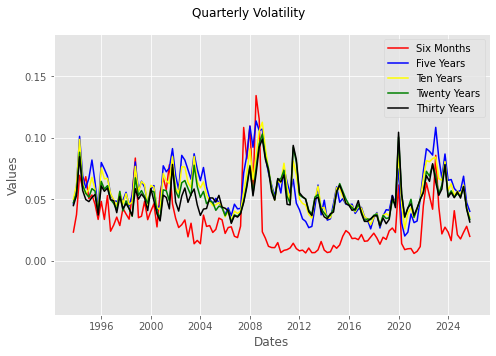

In [9]:
# populate data list according to DataFrame columns of quarterly standard deviations
data=[quarterly_sigma_df['dgs6mo'],
      quarterly_sigma_df['dgs5'],
      quarterly_sigma_df['dgs10'],
      quarterly_sigma_df['dgs20'],
      quarterly_sigma_df['dgs30']]
series=['Six Months',
        'Five Years',
        'Ten Years',
        'Twenty Years',
        'Thirty Years']

title='Quarterly Volatility'
plot_vol_corr_results(data,series,title)

## The graph leads to two clear conclusions:

1. Rate variability has changed over time. It spiked during the financial crisis and dropped significantly following the Federal Reserve's massive balance sheet expansion.  
2. The difference in variability among rates is tied to the maturity of the par yields. Six-month and five-year par yields show greater variability compared to ten, twenty, and thirty-year par yields. Although the variability of the longer maturities (ten, twenty, and thirty-year) is generally similar, it is not identical.

## <font color='green'>Application: Plot the volatility for the ten, twenty, and thirty-year par yields: 1993 - 2025</font>
<div style="
    border-left: 12px solid green;
    line-height: 1.5;
    padding: 15px">

 see [Chapter Eight Hints: Plot the volatility for the ten, twenty, and thirty-year par yields](https://colab.research.google.com/drive/1WL30MXvTfn3tTNQaaas2bmHn3G5E3lK4#scrollTo=C4mk68PTMOWJ), and check the [expected results here](https://colab.research.google.com/drive/1jULdrPyul6Xs5Zrm4ysXezNNuJG7K6l6#scrollTo=C4mk68PTMOWJ).

</div>    

## Plotting the quarterly correlations of six month with longer maturity par yields

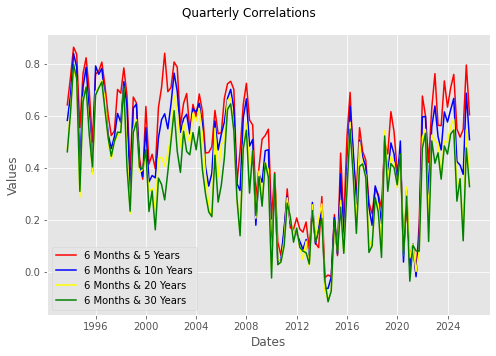

In [10]:
data=[quarterly_corr_df['_6_mo_5_y'],
      quarterly_corr_df['_6_mo_10_y'],
      quarterly_corr_df['_6_mo_20_y'],
      quarterly_corr_df['_6_mo_30_y']]
series=['6 Months & 5 Years',
        '6 Months & 10n Years',
        '6 Months & 20 Years',
        '6 Months & 30 Years']
title='Quarterly Correlations'
plot_vol_corr_results(data,series,title)

The correlation between the six-month yield and the five, ten, twenty, and thirty-year yields is highly volatile, ranging from greater than 0.8 to negative figures. The highest points for these correlations were observed during the 2008 financial crisis, the 2020 pandemic, and the most recent period marked by multiple increases in the target rates for the FED funds.

## Plotting the quarterly correlations of five year with ten, twenty, and thirty year par yields

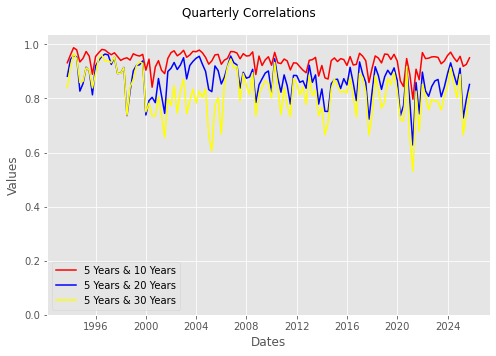

In [11]:
data=[quarterly_corr_df['_5_y_10_y'],
      quarterly_corr_df['_5_y_20_y'],
      quarterly_corr_df['_5_y_30_y']]
series=['5 Years & 10 Years',
        '5 Years & 20 Years',
        '5 Years & 30 Years']
title='Quarterly Correlations'
plot_vol_corr_results(data,series,title)

The correlation between five-year par yields and longer-maturity par yields is more pronounced and less variable than that observed for six-month par yields; However, these five-year correlations still show a significant range, varying from over 0.9 to under 0.6. This pattern mirrors, in a less extreme way, the results found for the six-month maturity.


## Plotting the quarterly correlations of ten year with twenty and thirty year par yields

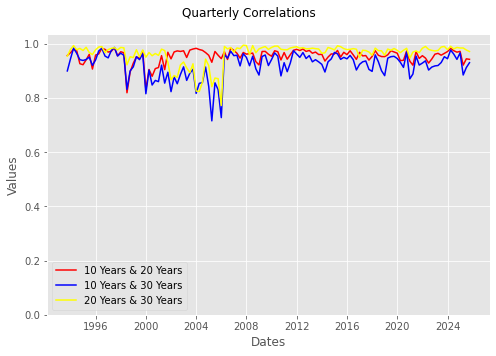

In [12]:
data=[quarterly_corr_df['_10_y_20_y'],
      quarterly_corr_df['_10_y_30_y'],
      quarterly_corr_df['_20_y_30_y']]
series=['10 Years & 20 Years',
        '10 Years & 30 Years',
        '20 Years & 30 Years']
title='Quarterly Correlations'
plot_vol_corr_results(data,series,title)

## The relevance of the par yield data

Interest rates generally trend together, though they rarely move in perfect unison. Longer-term rates show the closest correlations, but the relations are imperfect and often diverge significantly. The way rates behave is a crucial factor when using duration. Duration measures a bond's price change in response to a change in its own yield-to-maturity, but it will inaccurately predict the price change of a bond that experiences a different change in its yield to maturity. Caution is necessary when using duration to assess the interest rate risk of various bonds and when calculating hedges against interest rate movements. The forthcoming notebook, *Changing Slope and Shape of Term Structure*, will further explore how effective duration hedges are when interest rates do not change in parallel.  A convexity trade requires a long position and short position in bonds that is duration neutral.  With non-parallel changes in interest rates, the results of the convexity trade are often profitable but also unpredictable.
